In [1]:
ROOT = "zigzag_results/gtsrb"

MODELS = {
    'vit_l_16': 'ViTl16',
    'vit_b_32': 'ViTb32',
    'resnet34': 'ResNet34'
}

N_COMPONENTS = [3, 4, 5]
PLOT_COMPONENT = 4

In [2]:
import os
import typing

def plan(model: str, n_components: int) -> typing.List[typing.Tuple[str, str, int]]:
    folder = f"{ROOT}/{model}"
    hs_folder = (
        f"{folder}/hidden_states"
        if os.path.exists(f"{folder}/hidden_states")
        else f"{folder}/features"
    )
    
    layers = os.listdir(hs_folder)
    if model == "vit_l_16" or model == "vit_b_32":
        layers = layers[1:]

    plan = []
    for hidden_state in layers:
        hs_no_ext = hidden_state[:hidden_state.index('.')]
        out_file = f"{folder}/spaces/{hs_no_ext}/{n_components}.txt"
        plan.append((f"{hs_folder}/{hs_no_ext}", out_file, n_components))
    return plan

In [3]:
import zigzag.space

params = []
for model in MODELS.keys():
    for n_components in N_COMPONENTS:
        params.extend(plan(model, n_components))
zigzag.space.process_bulk(params, n_jobs=8)
None

100%|██████████| 159/159 [28:19<00:00, 10.69s/it]
d:\Programs\Programming\Python\lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [4]:
import pandas

report = []
for model, title in MODELS.items():
    for n_components in N_COMPONENTS:
        item = zigzag.space.make_report(plan(model, n_components))
        report.append({'model': title, 'n_components': n_components, **item})

report = pandas.DataFrame(report)
report.to_csv(f"{ROOT}/spaces_report.csv")
report

100%|██████████| 17/17 [00:00<00:00, 8308.46it/s]


,model,n_components,layer_1,layer_2,layer_3,layer_4,layer_5,layer_6,layer_7,layer_8,...,layer_15,layer_16,layer_17,layer_18,layer_19,layer_20,layer_21,layer_22,layer_23,layer_24
0,ViTl16,3,"53.2%\n(3, 2, 2)\n(3, 2, 2)","19.7%\n(2, 1, 6)\n(2, 1, 6)","19.2%\n(2, 4, 1)\n(2, 4, 1)","18.8%\n(2, 2, 12)\n(2, 2, 12)","18.3%\n(2, 5, 5)\n(2, 5, 5)","18.1%\n(2, 1, 1)\n(2, 1, 1)","18.0%\n(2, 1, 4)\n(2, 1, 4)","17.9%\n(2, 11, 3)\n(2, 11, 3)",...,"17.1%\n(2, 2, 1)\n(2, 2, 1)","17.2%\n(2, 1, 4)\n(2, 1, 4)","17.2%\n(2, 1, 4)\n(2, 1, 4)","38.3%\n(2, 1, 5)\n(2, 1, 5)","33.4%\n(2, 3, 1)\n(2, 3, 1)","29.2%\n(2, 1, 5)\n(2, 1, 5)","26.3%\n(2, 3, 1)\n(2, 3, 1)","23.4%\n(3, 2, 1)\n(3, 2, 1)","22.1%\n(2, 2, 24)\n(2, 2, 24)","20.8%\n(2, 7, 7)\n(2, 7, 7)"
1,ViTl16,4,"58.7%\n(3, 1, 6, 1)\n(3, 1, 6, 1)","22.8%\n(3, 1, 4, 2)\n(3, 1, 4, 2)","22.2%\n(3, 17, 1, 2)\n(3, 17, 1, 2)","21.9%\n(6, 1, 1, 5)\n(6, 1, 1, 5)","21.3%\n(2, 5, 1, 3)\n(2, 5, 1, 3)","21.1%\n(6, 2, 2, 5)\n(6, 2, 2, 5)","21.0%\n(3, 16, 3, 2)\n(3, 16, 3, 2)","20.9%\n(4, 2, 18, 2)\n(4, 2, 18, 2)",...,"20.0%\n(3, 4, 1, 1)\n(3, 4, 1, 1)","20.1%\n(2, 2, 5, 1)\n(2, 2, 5, 1)","20.1%\n(2, 2, 5, 1)\n(2, 2, 5, 1)","42.6%\n(3, 8, 3, 3)\n(3, 8, 3, 3)","37.8%\n(3, 1, 1, 4)\n(3, 1, 1, 4)","33.7%\n(3, 1, 1, 2)\n(3, 1, 1, 2)","30.6%\n(2, 8, 9, 2)\n(2, 8, 9, 2)","27.3%\n(2, 1, 1, 1)\n(2, 1, 1, 1)","25.8%\n(2, 3, 1, 1)\n(2, 3, 1, 1)","24.2%\n(3, 6, 4, 1)\n(3, 6, 4, 1)"
2,ViTl16,5,"62.9%\n(2, 2, 6, 1, 0)\n(2, 2, 6, 1, 0)","25.6%\n(3, 3, 3, 1, 0)\n(3, 3, 3, 1, 0)","25.0%\n(3, 2, 1, 5, 0)\n(3, 2, 1, 5, 0)","24.7%\n(2, 1, 1, 2, 0)\n(2, 1, 1, 2, 0)","24.2%\n(3, 1, 4, 4, 0)\n(3, 1, 4, 4, 0)","23.9%\n(4, 1, 1, 5, 0)\n(4, 1, 1, 5, 0)","23.8%\n(5, 1, 5, 2, 0)\n(5, 1, 5, 2, 0)","23.7%\n(2, 1, 4, 1, 0)\n(2, 1, 4, 1, 0)",...,"22.7%\n(2, 1, 3, 4, 0)\n(2, 1, 3, 4, 0)","22.9%\n(2, 1, 1, 10, 1)\n(2, 1, 1, 10, 1)","22.9%\n(2, 1, 1, 10, 1)\n(2, 1, 1, 10, 1)","46.5%\n(3, 2, 8, 1, 1)\n(3, 2, 8, 1, 1)","41.4%\n(3, 2, 2, 2, 0)\n(3, 2, 2, 2, 0)","37.4%\n(3, 6, 1, 1, 0)\n(3, 6, 1, 1, 0)","34.4%\n(2, 6, 1, 1, 0)\n(2, 6, 1, 1, 0)","30.7%\n(2, 1, 6, 6, 0)\n(2, 1, 6, 6, 0)","29.0%\n(2, 5, 10, 4, 0)\n(2, 5, 10, 4, 0)","27.2%\n(10, 1, 1, 1, 1)\n(10, 1, 1, 1, 1)"
3,ViTb32,3,"27.7%\n(2, 0, 0)\n(2, 0, 0)","18.9%\n(2, 8, 1)\n(2, 8, 1)","20.0%\n(2, 4, 0)\n(2, 4, 0)","21.6%\n(2, 5, 1)\n(2, 5, 1)","27.8%\n(2, 0, 0)\n(2, 0, 0)","23.3%\n(2, 1, 0)\n(2, 1, 0)","24.8%\n(2, 1, 0)\n(2, 1, 0)","23.2%\n(1, 4, 0)\n(1, 4, 0)",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ViTb32,4,"32.0%\n(2, 0, 0, 0)\n(2, 0, 0, 0)","21.9%\n(2, 5, 7, 0)\n(2, 5, 7, 0)","23.0%\n(2, 2, 1, 1)\n(2, 2, 1, 1)","24.3%\n(2, 11, 3, 0)\n(2, 11, 3, 0)","32.2%\n(1, 2, 0, 0)\n(1, 2, 0, 0)","26.9%\n(2, 2, 0, 0)\n(2, 2, 0, 0)","29.0%\n(3, 6, 0, 0)\n(3, 6, 0, 0)","27.5%\n(2, 1, 1, 0)\n(2, 1, 1, 0)",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,ViTb32,5,"36.0%\n(2, 0, 0, 0, 0)\n(2, 0, 0, 0, 0)","24.5%\n(3, 1, 2, 0, 0)\n(3, 1, 2, 0, 0)","25.7%\n(4, 1, 1, 0, 0)\n(4, 1, 1, 0, 0)","26.9%\n(5, 3, 1, 0, 0)\n(5, 3, 1, 0, 0)","35.5%\n(3, 3, 0, 0, 0)\n(3, 3, 0, 0, 0)","30.0%\n(3, 4, 1, 0, 0)\n(3, 4, 1, 0, 0)","32.8%\n(2, 5, 1, 0, 0)\n(2, 5, 1, 0, 0)","30.5%\n(3, 1, 1, 0, 0)\n(3, 1, 1, 0, 0)",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,ResNet34,3,"35.4%\n(2, 45, 7)\n(2, 45, 7)","33.2%\n(4, 8, 1)\n(4, 8, 1)","17.2%\n(2, 1, 0)\n(2, 1, 0)","17.2%\n(2, 8, 0)\n(2, 8, 0)","16.9%\n(3, 1, 0)\n(3, 1, 0)","16.6%\n(2, 1, 3)\n(2, 1, 3)","18.1%\n(2, 3, 1)\n(2, 3, 1)","15.5%\n(3, 1, 2)\n(3, 1, 2)",...,"19.6%\n(5, 3, 4)\n(5, 3, 4)","16.0%\n(2, 9, 3)\n(2, 9, 3)","15.7%\n(2, 1, 1)\n(2, 1, 1)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,ResNet34,4,"40.8%\n(4, 1, 3, 2)\n(4, 1, 3, 2)","38.2%\n(2, 1, 1, 1)\n(2, 1, 1, 1)","19.4%\n(2, 1, 4, 0)\n(2, 1, 4, 0)","19.4%\n(3, 1, 1, 0)\n(3, 1, 1, 0)","19.2%\n(2, 1, 2, 0)\n(2, 1, 2, 0)","19.1%\n(8, 5, 1, 0)\n(8, 5, 1, 0)","21.0%\n(2, 15, 6, 0)\n(2, 15, 6, 0)","18.5%\n(3, 1, 3, 0)\n(3, 1, 3, 0)",...,"22.1%\n(2, 1, 1, 1)\n(2, 1, 1, 1)","18.7%\n(4, 103, 1, 0)\n(4, 103, 1, 0)","18.0%\n(2, 1, 1, 0)\n

100%|██████████| 17/17 [00:00<00:00, 8497.58it/s]


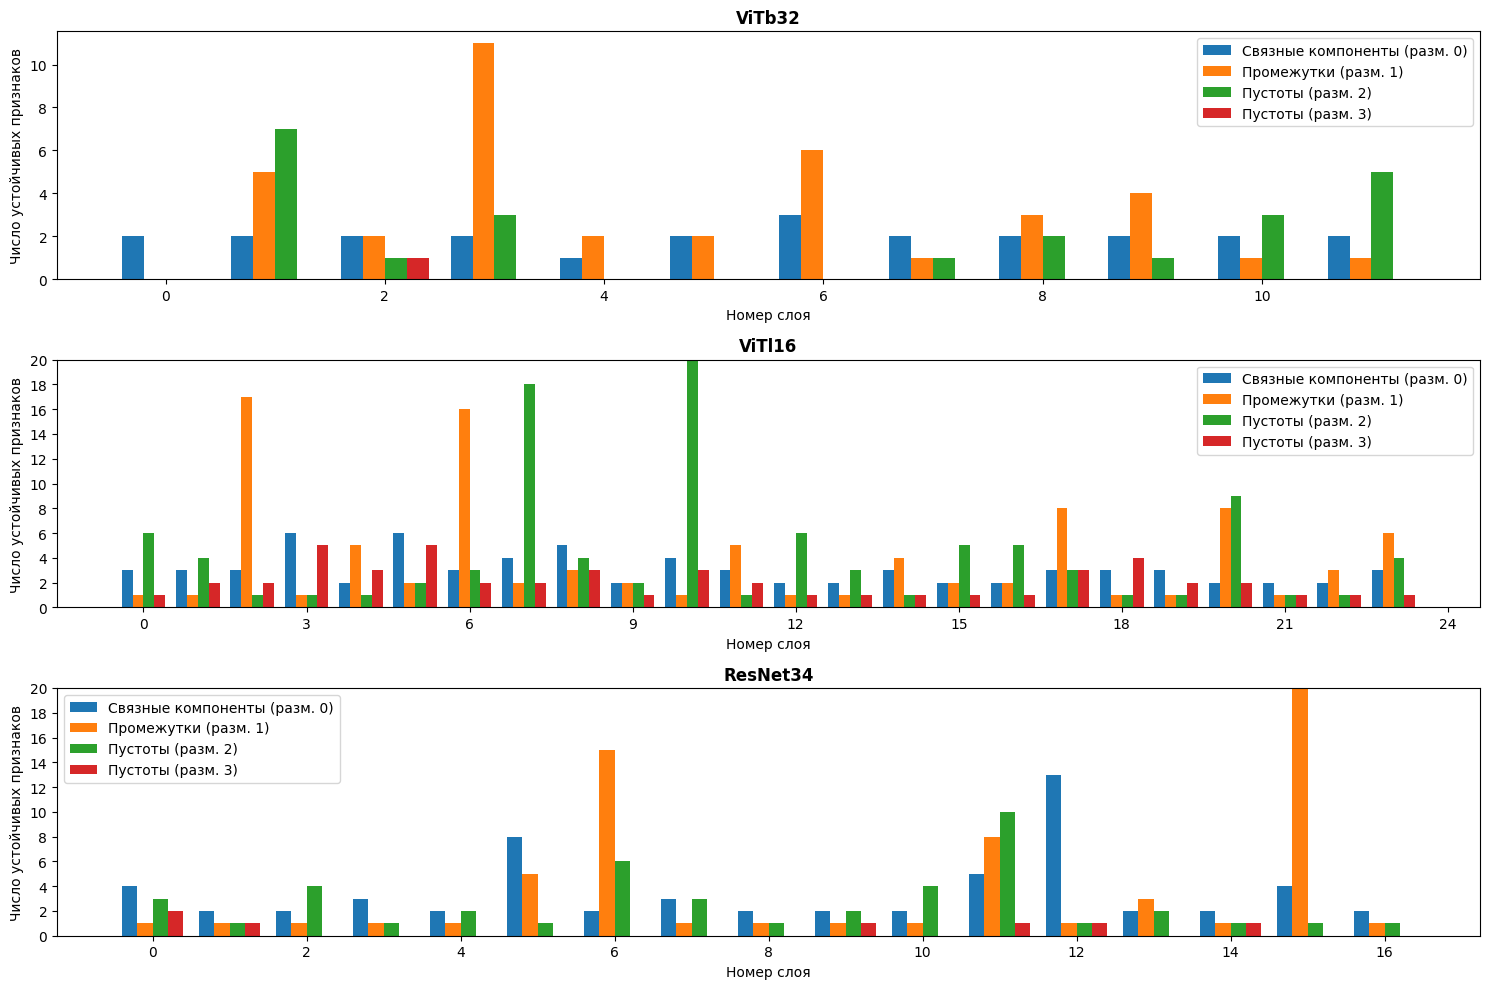

In [5]:
import matplotlib.pyplot as plt

AX_IDX = { 'vit_l_16': 1, 'vit_b_32': 0, 'resnet34': 2 }
fig, axes = plt.subplots(3, 1, figsize = (15, 10))
for model, title in MODELS.items():
    ax = axes.flat[AX_IDX[model]]
    ax.set_title(title, fontweight='bold')
    zigzag.space.plot(plan(model, PLOT_COMPONENT), ax)
    ax.legend(loc='best')
    if model != "vit_b_32":
        ax.set_ylim((0, 20))

fig.tight_layout()
fig.savefig(f"{ROOT}/spaces_plots.png")
fig.savefig(f"{ROOT}/spaces_plots.svg")